In [24]:
import numpy as np
import pandas as pd

In [25]:
folder = './preds_csv/'

In [26]:
df = pd.read_csv(folder + 'index.csv')

In [28]:
df[['WGATAR_id', 'type']] = df["seq_id"].str.rsplit("_", n=1, expand=True)

In [29]:
df

,seq_id,kind,value,npz_path,WGATAR_id,type
0,WGATAR_1_original,sequence,ATGAAACTTTCTTCTTTGAAGAAAAACTGACCTCCTCCTCTTTGTT...,./preds_csv/WGATAR_1_original.npz,WGATAR_1,original
1,WGATAR_1_modified,sequence,ATGAAACTTTCTTCTTTGAAGAAAAACTGACCTCCTCCTCTTTGTT...,./preds_csv/WGATAR_1_modified.npz,WGATAR_1,modified
2,WGATAR_2_original,sequence,taaattggattgcattactttaaaagcctctgaaagcaaatagaca...,./preds_csv/WGATAR_2_original.npz,WGATAR_2,original
3,WGATAR_2_modified,sequence,taaattggattgcattactttaaaagcctctgaaagcaaatagaca...,./preds_csv/WGATAR_2_modified.npz,WGATAR_2,modified
4,WGATAR_3_original,sequence,ACATTGATAAGGGCTCAGTTTGCAGCAATAAATTCAGATGGAAACC...,./preds_csv/WGATAR_3_original.npz,WGATAR_3,original
...,...,...,...,...,...,...
5159,WGATAR_2580_original,sequence,tactgaagctacctgtgttatcttttttccccacattttggctgca...,./preds_csv/WGATAR_2580_original.npz,WGATAR_2580,original
5160,WGATAR_2581_modified,sequence,CACAGGCCACACCCAGAGAGCTAGTCCTGGGGCAGGGAGCGCCTCT...,./preds_csv/WGATAR_2581_modified.npz,WGATAR_2581,modified
5161,WGATAR_2581_original,sequence,CACAGGCCACACCCAGAGAGCTAGTCCTGGGGCAGGGAGCGCCTCT...,./preds_csv/WGATAR_2581_original.npz,WGATAR_2581,original
5162,WGATAR_2582_original,sequence,GCCACACCACAGGCCACACCACGGACCACAGGCCACACCCAGAGAG...,./preds_csv/WGATAR_2582_original.npz,WGATAR_2582,original


In [31]:
pred = []
for i, r in df.iterrows():
    d = r['npz_path']
    data = np.load(d)
    pred.append(data['log_counts'][0])    

In [35]:
df['cnn_atac'] = pred

In [36]:
df = df[['WGATAR_id', 'type', 'cnn_atac']]

In [38]:
df_o = df[df['type'] == 'original']
df_m = df[df['type'] == 'modified']

In [41]:
df_all = df_o.merge(df_m, on = 'WGATAR_id')

In [42]:
df_all

,WGATAR_id,type_x,cnn_atac_x,type_y,cnn_atac_y
0,WGATAR_1,original,4.098376,modified,3.469574
1,WGATAR_2,original,3.599241,modified,3.265302
2,WGATAR_3,original,3.763755,modified,3.767798
3,WGATAR_4,original,3.591118,modified,3.405770
4,WGATAR_5,original,3.555527,modified,3.534796
...,...,...,...,...,...
2577,WGATAR_2578,original,3.704630,modified,3.737992
2578,WGATAR_2579,original,4.383873,modified,4.110777
2579,WGATAR_2580,original,4.848775,modified,4.450229
2580,WGATAR_2581,original,5.147696,modified,5.123269


([<matplotlib.axis.XTick at 0x1554e24b3670>,
 [Text(0, 0, 'original'), Text(1, 0, 'modified')])

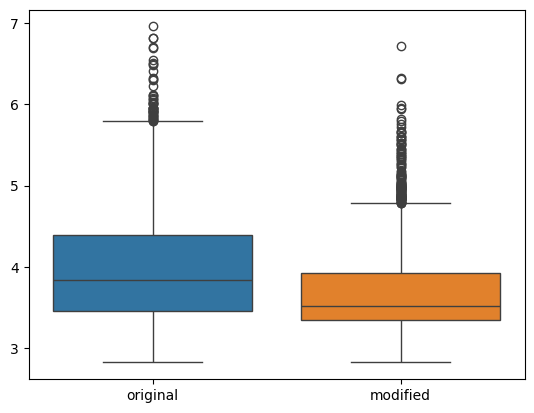

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot([df_all['cnn_atac_x'], df_all['cnn_atac_y']],showfliers=True)
plt.xticks([0,1],['original', 'modified'])

In [46]:
df_all['delta_cnn_atac'] = df_all['cnn_atac_x'] - df_all['cnn_atac_y']

In [47]:
df_all.to_pickle('delta_atac.pkl')